# 🩺 Diabetes Prediction — Clasificación Binaria con PyTorch
## Reto proyecto 2 · Construye una red neuronal feed-forward para realizar predicciones

---

Este notebook entrena una red neuronal feed-forward para predecir si una persona  
tiene diabetes usando el dataset *Pima Indians Diabetes Database*.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y exploración del dataset |
| 2️⃣ | Limpieza y preparación de datos |
| 3️⃣ | Normalización, partición y conversión a tensores |
| 4️⃣ | Construcción de la red neuronal (64 → 32 → Sigmoid) |
| 5️⃣ | Entrenamiento con BCELoss + Adam |
| 6️⃣ | Evaluación — Accuracy, F1 Score, Classification Report |

> **Dataset:** `diabetes.csv` — 768 registros · 9 columnas  
> **Objetivo:** predecir `Outcome` (0 = no diabetes · 1 = diabetes)  
> **Ruta:** `/workspace/diabetes.csv`


---
## 0. Importación de librerías


In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix)

# ── Reproducibilidad ─────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ── Device: usa GPU si está disponible, CPU en caso contrario ────────────
# Mover modelo y tensores al mismo device permite ejecutar sin cambios
# en entornos con GPU. En CPU, .to(device) es una operación sin coste.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_PATH      = os.environ.get("DIABETES_PATH", "workspace/diabetes.csv")
EPOCHS          = 100
LR              = 0.001
HIDDEN1         = 64
HIDDEN2         = 32
THRESHOLD       = 0.5
USE_DATALOADER  = False   # True → mini-batches con DataLoader
                           # Para n=576 (train) el batch completo es adecuado;
                           # activar si el dataset creciera a >5 000 filas.
BATCH_SIZE      = 32      # tamaño de mini-batch si USE_DATALOADER=True

print("✅ Librerías cargadas correctamente.")
print(f"   PyTorch {torch.__version__}")
print(f"   Device:  {DEVICE}")
print(f"📂 Ruta:   {INPUT_PATH}")
print(f"   USE_DATALOADER={USE_DATALOADER}  BATCH_SIZE={BATCH_SIZE}")


✅ Librerías cargadas correctamente.
   PyTorch 2.10.0+cpu
   Device:  cpu
📂 Ruta:   workspace/diabetes.csv
   USE_DATALOADER=False  BATCH_SIZE=32


---
## 1. Carga y Exploración del Dataset


In [33]:
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"\n❌ No se encontró: {INPUT_PATH}\n"
        "   Coloca diabetes.csv en /workspace/ antes de ejecutar."
    )

df = pd.read_csv(INPUT_PATH)
print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n📋 Columnas y tipos:")
for col in df.columns:
    print(f"  · {col:28s} dtype={df[col].dtype}")


📐 Dimensiones: 768 filas × 9 columnas

📋 Columnas y tipos:
  · Pregnancies                  dtype=int64
  · Glucose                      dtype=int64
  · BloodPressure                dtype=int64
  · SkinThickness                dtype=int64
  · Insulin                      dtype=int64
  · BMI                          dtype=float64
  · DiabetesPedigreeFunction     dtype=float64
  · Age                          dtype=int64
  · Outcome                      dtype=int64


In [34]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
print("📊 Estadísticas descriptivas:")
df.describe().round(2)


📊 Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


📊 Distribución de Outcome:
  · 0 (no diabetes):  500  (65.1%)
  · 1 (diabetes):     268  (34.9%)
  Ratio desbalance: 1.87:1


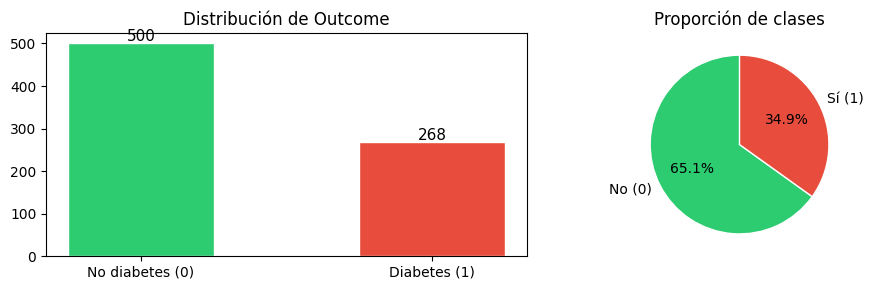

In [36]:
# Distribución de la variable objetivo
counts = df["Outcome"].value_counts()
print(f"📊 Distribución de Outcome:")
print(f"  · 0 (no diabetes): {counts[0]:4d}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  · 1 (diabetes):    {counts[1]:4d}  ({counts[1]/len(df)*100:.1f}%)")
print(f"  Ratio desbalance: {counts[0]/counts[1]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(["No diabetes (0)", "Diabetes (1)"],
            counts.values, color=["#2ecc71","#e74c3c"],
            edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)
axes[0].set_title("Distribución de Outcome")

axes[1].pie(counts.values, labels=["No (0)","Sí (1)"],
            colors=["#2ecc71","#e74c3c"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Proporción de clases")
plt.tight_layout(); plt.show()


---
## 2. Limpieza de Datos

### 2.1 Valores nulos explícitos


In [37]:
nulos = df.isnull().sum()
print(f"🔍 Valores nulos: {nulos.sum()}")
print(nulos.to_string())


🔍 Valores nulos: 0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0


### 2.2 Zeros fisiológicamente imposibles

En este dataset, `0` en columnas como `Glucose`, `BloodPressure`, `SkinThickness`,  
`Insulin` o `BMI` es fisiológicamente imposible — representa datos faltantes codificados.  
Los reemplazamos con la **mediana** de cada columna (robusta a outliers).


In [38]:
COLS_ZERO_INVALID = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print(f"🔍 Ceros fisiológicamente imposibles (antes de la imputación):\n")
print(f"  {'Columna':<28}  {'N ceros':>8}  {'Mediana':>10}")
print("  " + "─" * 52)
for col in COLS_ZERO_INVALID:
    n_zeros = (df[col] == 0).sum()
    med     = df[col][df[col] != 0].median()
    print(f"  {col:<28}  {n_zeros:>8}  {med:>10.2f}")
    df[col] = df[col].replace(0, df[col][df[col] != 0].median())

print(f"\n✅ Imputación completada. Zeros restantes:")
for col in COLS_ZERO_INVALID:
    print(f"  · {col:<28}: {(df[col] == 0).sum()}")


🔍 Ceros fisiológicamente imposibles (antes de la imputación):

  Columna                        N ceros     Mediana
  ────────────────────────────────────────────────────
  Glucose                              5      117.00
  BloodPressure                       35       72.00
  SkinThickness                      227       29.00
  Insulin                            374      125.00
  BMI                                 11       32.30

✅ Imputación completada. Zeros restantes:
  · Glucose                     : 0
  · BloodPressure               : 0
  · SkinThickness               : 0
  · Insulin                     : 0
  · BMI                         : 0


---
## 3. Preparación del Dataset

### 3.1 Separación features / target y partición 75/25


In [39]:
FEATURES = [c for c in df.columns if c != "Outcome"]
TARGET   = "Outcome"

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

# test_size=0.25, shuffle=True explícito
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42
)
print(f"📊 División del dataset:")
print(f"  Train: {len(X_train):4d} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):4d}  ({len(X_test)/len(X)*100:.1f}%)")


📊 División del dataset:
  Train:  576 (75.0%)
  Test:   192  (25.0%)


### 3.2 Normalización con StandardScaler

In [40]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit SOLO en train
X_test  = scaler.transform(X_test)        # transform en test

print(f"✅ StandardScaler aplicado a {len(FEATURES)} features.")
print(f"   Media global tras escalar:  {X_train.mean():.6f}  (≈ 0)")
print(f"   Std global tras escalar:    {X_train.std():.6f}   (≈ 1)")


✅ StandardScaler aplicado a 8 features.
   Media global tras escalar:  -0.000000  (≈ 0)
   Std global tras escalar:    1.000000   (≈ 1)


### 3.3 Conversión a tensores PyTorch

In [41]:
# Crear tensores y moverlos al device (CPU o GPU)
# .to(DEVICE) es no-op en CPU pero permite ejecutar sin cambios con GPU.
# Al recuperar datos con .numpy() siempre hacer .cpu() primero:
#   tensor.cpu().numpy()  — funciona en CPU y GPU
#   tensor.numpy()        — falla si el tensor está en GPU
X_train_t = torch.tensor(X_train).to(DEVICE)
X_test_t  = torch.tensor(X_test).to(DEVICE)
y_train_t = torch.tensor(y_train).unsqueeze(1).to(DEVICE)
y_test_t  = torch.tensor(y_test).unsqueeze(1).to(DEVICE)

print(f"✅ Tensores en device: {DEVICE}")
print(f"  X_train_t: {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"  y_train_t: {y_train_t.shape}  dtype={y_train_t.dtype}")
print(f"  X_test_t:  {X_test_t.shape}")
print(f"  y_test_t:  {y_test_t.shape}")

# ── DataLoader (opcional) ────────────────────────────────────────────────
if USE_DATALOADER:
    from torch.utils.data import TensorDataset, DataLoader
    train_ds     = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    print(f"\n  DataLoader activado: {len(train_loader)} mini-batches "
          f"de ~{BATCH_SIZE} muestras.")
else:
    train_loader = None
    print(f"\n  Entrenamiento en batch completo "
          f"(n={X_train_t.shape[0]}, USE_DATALOADER=False).")


✅ Tensores en device: cpu
  X_train_t: torch.Size([576, 8])  dtype=torch.float32
  y_train_t: torch.Size([576, 1])  dtype=torch.float32
  X_test_t:  torch.Size([192, 8])
  y_test_t:  torch.Size([192, 1])

  Entrenamiento en batch completo (n=576, USE_DATALOADER=False).


---
## 4. Construcción de la Red Neuronal

Arquitectura para clasificación binaria:

| Capa | Entrada | Salida | Activación |
|------|:-------:|:------:|:----------:|
| Oculta 1 | 8 | 64 | ReLU |
| Oculta 2 | 64 | 32 | ReLU |
| Salida | 32 | 1 | **Sigmoid** |

La función de activación **Sigmoid** en la salida transforma el valor a `[0, 1]`,  
interpretable como probabilidad de pertenecer a la clase 1 (diabetes).


In [42]:
class DiabetesNet(nn.Module):
    """Red neuronal feed-forward para clasificación binaria de diabetes.

    Arquitectura:
        Linear(input_dim → 64) → ReLU
        Linear(64 → 32)        → ReLU
        Linear(32 → 1)         → Sigmoid  (salida: probabilidad de diabetes)

    Nota de estabilidad numérica:
        El enunciado requiere explícitamente Sigmoid en la capa de salida,
        por lo que se mantiene. Como extensión, usar nn.BCEWithLogitsLoss
        (que fusiona LogSigmoid + BCELoss internamente) y eliminar la Sigmoid
        de la arquitectura ofrece mayor estabilidad numérica en precisión
        float32, al evitar el cálculo separado de log(sigmoid(x)).

    Args:
        input_dim: número de features de entrada (8 en este dataset).
    """

    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.fc1     = nn.Linear(input_dim, HIDDEN1)
        self.fc2     = nn.Linear(HIDDEN1, HIDDEN2)
        self.fc3     = nn.Linear(HIDDEN2, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Propagación hacia adelante.

        Args:
            x: tensor (batch_size, input_dim).
        Returns:
            Probabilidades en [0, 1] con shape (batch_size, 1).
        """
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.sigmoid(self.fc3(x))


model = DiabetesNet(input_dim=len(FEATURES)).to(DEVICE)
print(model)
print(f"   Device: {next(model.parameters()).device}")
print(f"\n📊 Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print()
print("  ℹ️  Nota: el enunciado requiere Sigmoid en la salida — se conserva.")
print("     Alternativa más estable numéricamente (extensión opcional):")
print("       · Eliminar self.sigmoid de la arquitectura")
print("       · Sustituir nn.BCELoss() por nn.BCEWithLogitsLoss()")
print("     BCEWithLogitsLoss fusiona log(sigmoid(x)) en una sola operación,")
print("     evitando desbordamiento en valores extremos del logit.")


DiabetesNet(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
   Device: cpu

📊 Parámetros totales: 2,689

  ℹ️  Nota: el enunciado requiere Sigmoid en la salida — se conserva.
     Alternativa más estable numéricamente (extensión opcional):
       · Eliminar self.sigmoid de la arquitectura
       · Sustituir nn.BCELoss() por nn.BCEWithLogitsLoss()
     BCEWithLogitsLoss fusiona log(sigmoid(x)) en una sola operación,
     evitando desbordamiento en valores extremos del logit.


---
## 5. Entrenamiento del Modelo

- **BCELoss** (Binary Cross-Entropy): función de pérdida estándar para clasificación binaria.  
  Penaliza fuertemente las predicciones confiadas pero erróneas.
- **Adam** con `lr=0.001` — optimizador adaptativo con convergencia robusta.


In [43]:
def train(model, criterion, optimizer, X_t, y_t,
          epochs: int = EPOCHS,
          print_every: int = 10,
          loader=None) -> list:
    """Entrena el modelo en batch completo o con DataLoader.

    Args:
        model:       red neuronal a entrenar (ya en el device correcto).
        criterion:   función de pérdida (BCELoss).
        optimizer:   optimizador (Adam).
        X_t:         tensor de features (usado si loader=None).
        y_t:         tensor de targets (usado si loader=None).
        epochs:      número de épocas.
        print_every: imprimir métricas cada N épocas.
        loader:      DataLoader opcional; si no es None usa mini-batches.

    Returns:
        Lista con la pérdida media por época.
    """
    loss_history = []
    model.train()

    for epoch in range(1, epochs + 1):
        if loader is not None:
            # ── Mini-batch con DataLoader ─────────────────────────────────
            batch_losses = []
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward(); optimizer.step()
                batch_losses.append(loss.item())
            epoch_loss = float(np.mean(batch_losses))
        else:
            # ── Full-batch ────────────────────────────────────────────────
            optimizer.zero_grad()
            probs      = model(X_t)
            epoch_loss = criterion(probs, y_t).item()
            criterion(probs, y_t).backward()
            optimizer.step()

        loss_history.append(epoch_loss)

        if epoch % print_every == 0 or epoch == 1:
            with torch.no_grad():
                probs_all  = model(X_t)
                acc_train  = ((probs_all >= THRESHOLD).float() == y_t
                              ).float().mean().item()
            print(f"  Época {epoch:>3}/{epochs}  — "
                  f"BCE Loss: {epoch_loss:.4f}  "
                  f"Acc train: {acc_train:.4f}")
    return loss_history


criterion    = nn.BCELoss()
optimizer    = Adam(model.parameters(), lr=LR)
loss_history = train(model, criterion, optimizer,
                     X_train_t, y_train_t,
                     loader=train_loader)

print(f"\n✅ Entrenamiento completado. Loss final: {loss_history[-1]:.4f}")


  Época   1/100  — BCE Loss: 0.6842  Acc train: 0.6545
  Época  10/100  — BCE Loss: 0.6322  Acc train: 0.6545
  Época  20/100  — BCE Loss: 0.5829  Acc train: 0.6597
  Época  30/100  — BCE Loss: 0.5380  Acc train: 0.7066
  Época  40/100  — BCE Loss: 0.5004  Acc train: 0.7448
  Época  50/100  — BCE Loss: 0.4727  Acc train: 0.7674
  Época  60/100  — BCE Loss: 0.4523  Acc train: 0.7847
  Época  70/100  — BCE Loss: 0.4365  Acc train: 0.7865
  Época  80/100  — BCE Loss: 0.4241  Acc train: 0.7934
  Época  90/100  — BCE Loss: 0.4144  Acc train: 0.7969
  Época 100/100  — BCE Loss: 0.4065  Acc train: 0.8003

✅ Entrenamiento completado. Loss final: 0.4065


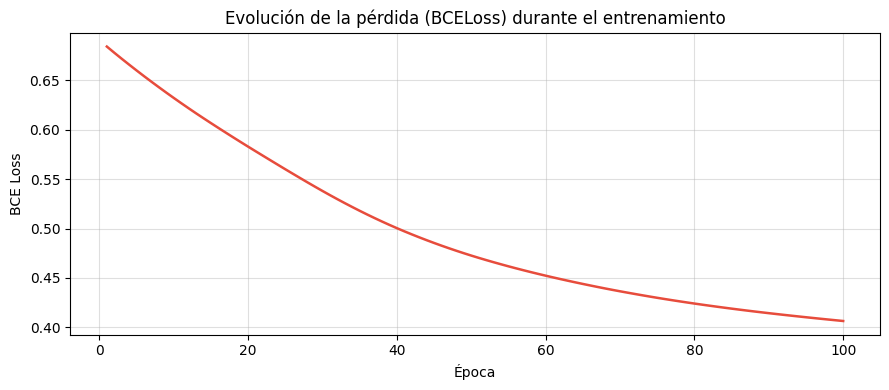

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPOCHS + 1), loss_history, color="#e74c3c", linewidth=1.8)
ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
ax.set_title("Evolución de la pérdida (BCELoss) durante el entrenamiento")
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


---
## 6. Evaluación del Modelo


In [45]:
from sklearn.metrics import roc_auc_score

model.eval()
with torch.no_grad():
    probs_test = model(X_test_t)

# Convertir probabilidades → clases binarias con umbral 0.5
# .cpu() antes de .numpy() garantiza compatibilidad con GPU:
# en CPU es una no-op; en GPU mueve el tensor a RAM antes de convertir.
y_prob = probs_test.cpu().numpy().flatten()
y_pred = (y_prob >= THRESHOLD).astype(int)
y_true = y_test_t.cpu().numpy().flatten().astype(int)

acc       = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred, zero_division=0)
precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
roc_auc   = roc_auc_score(y_true, y_prob)   # usa probabilidades, no clases

# Calcular FN explícitamente antes del print (evita error de formato en f-string)
fn = int(((y_true == 1) & (y_pred == 0)).sum())
n_diabetes_real = int((y_true == 1).sum())

print("📊 Métricas de evaluación en el conjunto de TEST:\n")
print(f"  {'Accuracy:':40s} {acc:.4f}  ({acc*100:.1f}%)")
print(f"  {'F1 Score     (clase 1 — diabetes):':40s} {f1:.4f}")
print(f"  {'Precisión    (clase 1 — diabetes):':40s} {precision:.4f}")
print(f"  {'Recall       (clase 1 — diabetes):':40s} {recall:.4f}")
print(f"  {'ROC-AUC:':40s} {roc_auc:.4f}")
print()
print("  ℹ️  En diagnóstico médico el recall de la clase positiva (diabetes)")
print("     es crítico: un valor bajo indica que el modelo no detecta")
print(f"     casos reales — falsos negativos: {fn} de {n_diabetes_real} "
      f"({fn/n_diabetes_real*100:.1f}% de los casos de diabetes no detectados).")
print()
print("─" * 55)
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred,
                             target_names=["No diabetes (0)", "Diabetes (1)"],
                             zero_division=0))


📊 Métricas de evaluación en el conjunto de TEST:

  Accuracy:                                0.7396  (74.0%)
  F1 Score     (clase 1 — diabetes):       0.6324
  Precisión    (clase 1 — diabetes):       0.6418
  Recall       (clase 1 — diabetes):       0.6232
  ROC-AUC:                                 0.8164

  ℹ️  En diagnóstico médico el recall de la clase positiva (diabetes)
     es crítico: un valor bajo indica que el modelo no detecta
     casos reales — falsos negativos: 26 de 69 (37.7% de los casos de diabetes no detectados).

───────────────────────────────────────────────────────

📋 Classification Report:

                 precision    recall  f1-score   support

No diabetes (0)       0.79      0.80      0.80       123
   Diabetes (1)       0.64      0.62      0.63        69

       accuracy                           0.74       192
      macro avg       0.72      0.71      0.72       192
   weighted avg       0.74      0.74      0.74       192



### 6.2 Curva ROC — análisis del umbral de decisión

> ⚠️ **Esta sección es una extensión opcional — no requerida por el enunciado.**

La curva ROC muestra el trade-off entre sensibilidad (TPR) y tasa de falsos positivos (FPR)  
para todos los umbrales posibles. El área bajo la curva (**ROC-AUC**) resume en un único  
número la capacidad discriminativa del modelo: 1.0 = perfecto, 0.5 = azar.


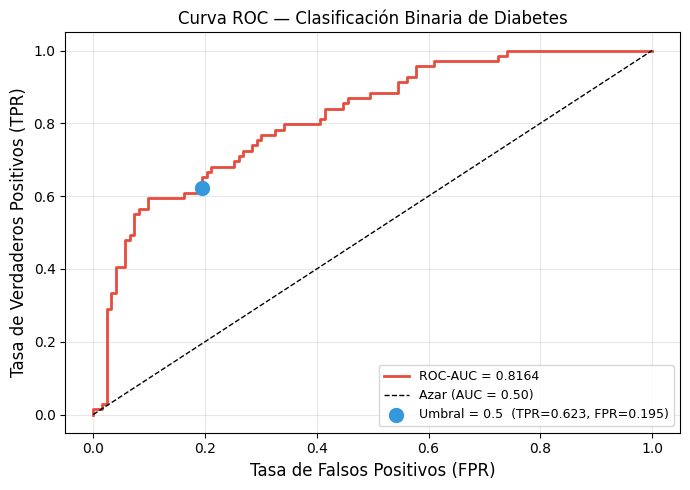

  ROC-AUC = 0.8164
  ✅ AUC ≥ 0.80 — buena capacidad discriminativa.
  El punto azul marca el umbral por defecto (0.5):
    · Sensibilidad (TPR): 0.6232
    · 1-Especificidad (FPR): 0.1951


In [46]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#e74c3c", linewidth=2,
        label=f"ROC-AUC = {roc_auc_val:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.50)")

# Marcar el punto correspondiente al umbral 0.5
idx_thresh = np.argmin(np.abs(thresholds - THRESHOLD))
ax.scatter(fpr[idx_thresh], tpr[idx_thresh],
           color="#3498db", s=100, zorder=5,
           label=f"Umbral = {THRESHOLD}  "
                 f"(TPR={tpr[idx_thresh]:.3f}, FPR={fpr[idx_thresh]:.3f})")

ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curva ROC — Clasificación Binaria de Diabetes")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"  ROC-AUC = {roc_auc_val:.4f}")
if roc_auc_val >= 0.80:
    print("  ✅ AUC ≥ 0.80 — buena capacidad discriminativa.")
elif roc_auc_val >= 0.70:
    print("  ✅ AUC ≥ 0.70 — capacidad discriminativa aceptable.")
else:
    print("  ⚠️  AUC < 0.70 — el modelo tiene dificultades para separar las clases.")
print(f"  El punto azul marca el umbral por defecto ({THRESHOLD}):")
print(f"    · Sensibilidad (TPR): {tpr[idx_thresh]:.4f}")
print(f"    · 1-Especificidad (FPR): {fpr[idx_thresh]:.4f}")


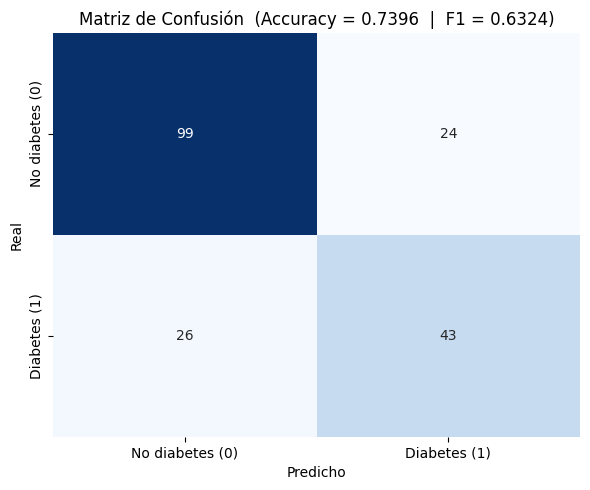

  Verdaderos Negativos (TN):  99  — no diabetes predicho correctamente
  Falsos Positivos      (FP):  24  — no diabetes predicho como diabetes
  Falsos Negativos      (FN):  26  — diabetes no detectada
  Verdaderos Positivos  (TP):  43  — diabetes predicha correctamente

  Sensibilidad (recall):  0.6232  — % diabetes detectados
  Especificidad:          0.8049  — % no-diabetes detectados


In [47]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No diabetes (0)", "Diabetes (1)"],
            yticklabels=["No diabetes (0)", "Diabetes (1)"],
            ax=ax, cbar=False)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de Confusión  (Accuracy = {acc:.4f}  |  F1 = {f1:.4f})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  Verdaderos Negativos (TN): {tn:3d}  — no diabetes predicho correctamente")
print(f"  Falsos Positivos      (FP): {fp:3d}  — no diabetes predicho como diabetes")
print(f"  Falsos Negativos      (FN): {fn:3d}  — diabetes no detectada")
print(f"  Verdaderos Positivos  (TP): {tp:3d}  — diabetes predicha correctamente")
print(f"\n  Sensibilidad (recall):  {tp/(tp+fn):.4f}  — % diabetes detectados")
print(f"  Especificidad:          {tn/(tn+fp):.4f}  — % no-diabetes detectados")


### 6.4 Extensión: `BCEWithLogitsLoss` — mayor estabilidad numérica

> ⚠️ **Esta sección es una extensión opcional — no requerida por el enunciado.**  
> El enunciado pide explícitamente Sigmoid en la salida, por lo que el modelo  
> principal lo conserva. Esta celda demuestra la alternativa numéricamente  
> más estable para referencia.

`BCEWithLogitsLoss` fusiona `Sigmoid + BCELoss` en una sola operación usando  
el truco `log(1 + exp(-x))` para valores grandes de `x`, evitando el  
desbordamiento en precisión `float32`.


In [48]:
# ── Versión con BCEWithLogitsLoss (sin Sigmoid en la salida) ────────────
class DiabetesNetLogits(nn.Module):
    """Variante de DiabetesNet sin Sigmoid — usa BCEWithLogitsLoss.
    Numéricamente más estable; la Sigmoid se aplica internamente en la loss.
    Para inferencia: torch.sigmoid(model(x)) convierte logits → probabilidades.
    """
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.fc1  = nn.Linear(input_dim, HIDDEN1)
        self.fc2  = nn.Linear(HIDDEN1, HIDDEN2)
        self.fc3  = nn.Linear(HIDDEN2, 1)
        self.relu = nn.ReLU()
        # Sin self.sigmoid — la loss la aplica internamente

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Devuelve logits (sin activar), NO probabilidades."""
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)   # logits en (-∞, +∞)


torch.manual_seed(42)
model_logits = DiabetesNetLogits(input_dim=len(FEATURES)).to(DEVICE)
crit_logits  = nn.BCEWithLogitsLoss()   # fusiona Sigmoid + BCE
opt_logits   = Adam(model_logits.parameters(), lr=LR)

loss_logits = train(model_logits, crit_logits, opt_logits,
                    X_train_t, y_train_t, print_every=EPOCHS)

# Inferencia: aplicar Sigmoid para convertir logits → probabilidades
model_logits.eval()
with torch.no_grad():
    logits_test   = model_logits(X_test_t)
    probs_logits  = torch.sigmoid(logits_test).cpu().numpy().flatten()

y_pred_logits = (probs_logits >= THRESHOLD).astype(int)
acc_l = accuracy_score(y_true, y_pred_logits)
f1_l  = f1_score(y_true, y_pred_logits, zero_division=0)

print(f"\n📊 Comparativa BCELoss vs BCEWithLogitsLoss:\n")
print(f"  {'Métrica':<20}  {'BCELoss + Sigmoid':>20}  {'BCEWithLogitsLoss':>20}")
print("  " + "─" * 65)
print(f"  {'Accuracy':<20}  {acc:>20.4f}  {acc_l:>20.4f}")
print(f"  {'F1 Score':<20}  {f1:>20.4f}  {f1_l:>20.4f}")
print(f"  {'Loss final':<20}  {loss_history[-1]:>20.4f}  {loss_logits[-1]:>20.4f}")
print()
print("  ℹ️  Las diferencias de rendimiento son mínimas en float32 normal.")
print("     BCEWithLogitsLoss previene NaN/Inf en casos extremos de logit.")


  Época   1/100  — BCE Loss: 0.6842  Acc train: 0.6545
  Época 100/100  — BCE Loss: 0.4065  Acc train: 0.7917

📊 Comparativa BCELoss vs BCEWithLogitsLoss:

  Métrica                  BCELoss + Sigmoid     BCEWithLogitsLoss
  ─────────────────────────────────────────────────────────────────
  Accuracy                            0.7396                0.7396
  F1 Score                            0.6324                0.6324
  Loss final                          0.4065                0.4065

  ℹ️  Las diferencias de rendimiento son mínimas en float32 normal.
     BCEWithLogitsLoss previene NaN/Inf en casos extremos de logit.
